# Lab 2a — First Regression Model
**SDA-AIE-111 · Day 1 · Hour 5 · 50 minutes · pairs**

**Objective.** Beat the Lab 1 dummy baseline with interpretable regression models for basket value; read residuals like a diagnostic; meet regularisation.

The target is `avg_basket_sar` — the customer's average basket value, which the CRM team uses to size retention vouchers. Because it is the target, it is **excluded from the features** (predicting a number from itself is not modelling).


In [1]:
# --- Course setup (identical in every lab) -----------------------------------
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

def find_repo_root() -> Path:
    """Locate the course repo root by looking for data/manafeth_customers.parquet."""
    for cand in [Path.cwd(), *Path.cwd().parents]:
        if (cand / "data" / "manafeth_customers.parquet").exists():
            return cand
    raise FileNotFoundError(
        "Course data not found — copy the Manafeth data package files into <repo>/data/")

ROOT = find_repo_root()
DATA = ROOT / "data"
sys.path.insert(0, str(ROOT / "src"))
print("repo root:", ROOT)

repo root: /home/claude/amlf/repo


In [2]:
from sklearn.model_selection import train_test_split

customers = pd.read_parquet(DATA / "manafeth_customers.parquet")
LEAKY = ["refund_issued", "support_ticket_after_snapshot", "next_month_orders"]

# Same split discipline as Lab 1 (same seed -> same rows)
X_all = customers.drop(columns=["churned_30d", "customer_id", *LEAKY])
y_all = customers["churned_30d"]
X_train, X_test, y_cls_train, y_cls_test = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=RANDOM_STATE)

# Regression target and numeric-only first pass (categoricals join in Module 3)
TARGET_REG = "avg_basket_sar"
num_cols = ["orders_per_month", "days_since_last_order", "tenure_months",
            "distinct_categories", "promo_usage_rate"]

y_basket = X_train[TARGET_REG]
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train[num_cols], y_basket, test_size=0.25, random_state=RANDOM_STATE)
print(X_tr.shape, X_val.shape)

(28800, 5) (9600, 5)


## Task 1 — Linear regression vs the dummy *(10 min)*

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean").fit(X_tr, y_tr)
print("dummy   MAE:", round(mean_absolute_error(y_val, dummy.predict(X_val)), 1), "SAR")

lin = LinearRegression().fit(X_tr, y_tr)
pred = lin.predict(X_val)
print("linear  MAE:", round(mean_absolute_error(y_val, pred), 1), "SAR")
print("R^2:", round(r2_score(y_val, pred), 3))
# The model earns its keep vs the dummy; now we ask HOW it fails.

# Coefficients in business units — only meaningful with the units attached
for name, coef in sorted(zip(num_cols, lin.coef_), key=lambda t: -abs(t[1])):
    print(f"{name:26s} {coef:+8.2f} SAR")

dummy   MAE: 36.4 SAR
linear  MAE: 27.7 SAR
R^2: 0.403
promo_usage_rate             -15.01 SAR
orders_per_month              +8.39 SAR
distinct_categories           +6.61 SAR
days_since_last_order         -0.14 SAR
tenure_months                 +0.04 SAR


## Task 2 — Residuals: the model's confession *(15 min)*

Plot residuals vs predictions. A funnel (errors growing with basket size) says: try a log target.


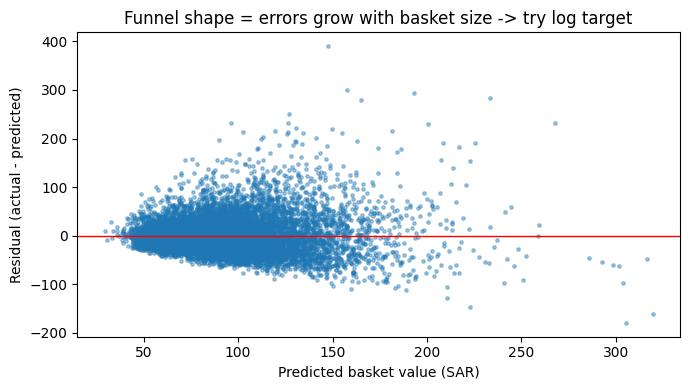

log-target MAE: 27.8 SAR


In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(pred, y_val - pred, s=6, alpha=0.4)
ax.axhline(0, color="red", lw=1)
ax.set_xlabel("Predicted basket value (SAR)")
ax.set_ylabel("Residual (actual - predicted)")
ax.set_title("Funnel shape = errors grow with basket size -> try log target")
plt.tight_layout()
plt.show()

# Refit on log1p(target); compare MAE in SAR after back-transform
lin_log = LinearRegression().fit(X_tr, np.log1p(y_tr))
pred_log = np.expm1(lin_log.predict(X_val))          # back-transform: expm1, NOT exp
assert (pred_log >= 0).all(), "negative baskets after back-transform = wrong inverse"
print("log-target MAE:", round(mean_absolute_error(y_val, pred_log), 1), "SAR")

## Task 3 — Ridge and lasso *(15 min)*

Regularisation is the first overfitting control. Sweep alpha logarithmically **on scaled features** and watch which lasso coefficients hit zero.


In [5]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

alphas = [0.01, 0.1, 1, 10, 100]
rows = []
for alpha in alphas:
    for name, Est in [("ridge", Ridge), ("lasso", Lasso)]:
        pipe = Pipeline([("scale", StandardScaler()), ("reg", Est(alpha=alpha))]).fit(X_tr, y_tr)
        rows.append({"model": name, "alpha": alpha,
                     "mae": mean_absolute_error(y_val, pipe.predict(X_val))})
sweep = pd.DataFrame(rows).pivot(index="alpha", columns="model", values="mae").round(2)
print(sweep)

lasso10 = Pipeline([("scale", StandardScaler()), ("reg", Lasso(alpha=10))]).fit(X_tr, y_tr)
zeroed = [c for c, w in zip(num_cols, lasso10["reg"].coef_) if w == 0]
print("lasso(alpha=10) zeroed out:", zeroed, " <- do these make domain sense to drop?")

model   lasso  ridge
alpha               
0.01    27.69  27.69
0.10    27.69  27.69
1.00    27.69  27.69
10.00   29.02  27.69
100.00  36.40  27.69
lasso(alpha=10) zeroed out: ['days_since_last_order', 'tenure_months', 'promo_usage_rate']  <- do these make domain sense to drop?


## Task 4 — Three-sentence summary *(10 min)*

Write it in this cell: best model, MAE in SAR, one surprising coefficient.

> …

**Commit:** `feat(lab2a): linear regression beats dummy; residual diagnosis`
